<a href="https://colab.research.google.com/github/Samiksha22911/AIML-LAB-EXPERIMENTS/blob/main/Multilinear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
"""
Experiment 2: Multi-Linear Regression
Dataset: Home Price Dataset (Rooms, Plot Area, Location, Age vs. Price)

- Extends linear regression to multiple variables
- Applies feature scaling / normalization
- One-hot encodes the categorical 'location' feature
"""

"\nExperiment 2: Multi-Linear Regression\nDataset: Home Price Dataset (Rooms, Plot Area, Location, Age vs. Price)\n\n- Extends linear regression to multiple variables\n- Applies feature scaling / normalization\n- One-hot encodes the categorical 'location' feature\n"

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
# ---------------------------------------------------------
# 1. Load dataset
# ---------------------------------------------------------
df = pd.read_csv("dataset_home_price_multi.csv")
print("Dataset shape:", df.shape)
print(df.head())

numeric_features = ["rooms", "plot_area_sqft", "age_years"]
categorical_features = ["location"]

X = df[numeric_features + categorical_features]
y = df["price_in_1000s"].values

Dataset shape: (140, 5)
   rooms  plot_area_sqft  location  age_years  price_in_1000s
0      7            3438     Rural         15           184.2
1      2            1992    Suburb          7           147.8
2      5            4055  Downtown         37           224.8
3      7            4136     Rural         11           213.4
4      7            3722  Downtown         23           261.7


In [4]:
# ---------------------------------------------------------
# 2. Preprocessing: scale numeric, one-hot encode categorical
# ---------------------------------------------------------
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(drop="first"), categorical_features),
    ]
)

In [5]:
# ---------------------------------------------------------
# 3. Train/test split
# ---------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:
# ---------------------------------------------------------
# 4. Build pipeline & train
# ---------------------------------------------------------
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['rooms', 'plot_area_sqft',
                                                   'age_years']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['location'])])),
                ('regressor', LinearRegression())])

In [7]:
# ---------------------------------------------------------
# 5. Evaluate
# ---------------------------------------------------------
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"\nMSE:  {mse:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R^2:  {r2:.3f}")

feature_names = (numeric_features +
                  list(model.named_steps["preprocessor"]
                       .named_transformers_["cat"]
                       .get_feature_names_out(categorical_features)))
coefs = model.named_steps["regressor"].coef_
print("\nFeature coefficients:")
for name, coef in zip(feature_names, coefs):
    print(f"  {name}: {coef:.3f}")



MSE:  188.966
RMSE: 13.746
R^2:  0.942

Feature coefficients:
  rooms: 38.971
  plot_area_sqft: 21.598
  age_years: -9.611
  location_Rural: -60.609
  location_Suburb: -34.234



Saved plot -> predicted_vs_actual.png


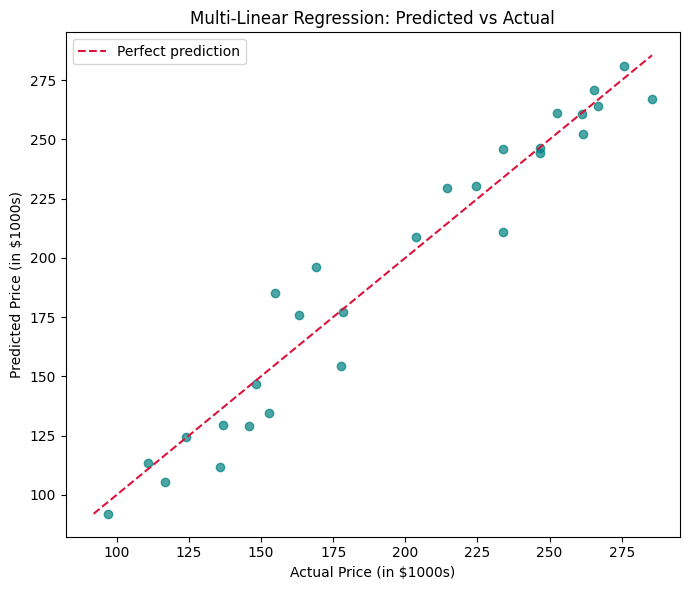

In [8]:
# ---------------------------------------------------------
# 6. Visualize: predicted vs actual
# ---------------------------------------------------------
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred, color="teal", alpha=0.7)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, color="crimson", linestyle="--", label="Perfect prediction")
plt.xlabel("Actual Price (in $1000s)")
plt.ylabel("Predicted Price (in $1000s)")
plt.title("Multi-Linear Regression: Predicted vs Actual")
plt.legend()
plt.tight_layout()
plt.savefig("predicted_vs_actual.png", dpi=150)
print("\nSaved plot -> predicted_vs_actual.png")
plt.show()